In [39]:
# Jupyter Notebook for model analysis
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os
import sys
from time import time
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, Dataset
from torch.utils.data import Subset

### Training mit verschiedenen Hyperparametern




In [32]:
training_num = 3 # number for iterations for the same hyperparameters for better mean
batch_sizes = [4, 8, 16, 64] # different batch_sizes
learning_rate = [0.1, 0.01, 0.001, 0.0001] # different learning rates
num_epochs = [10, 25, 50, 100]

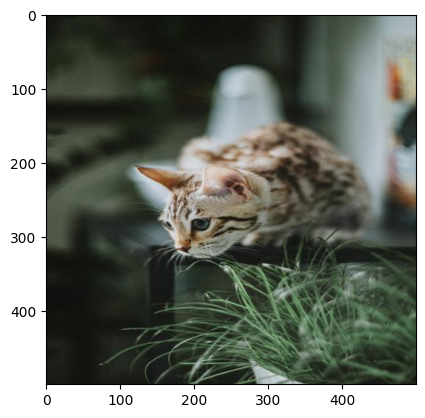

In [33]:
test_image = np.asarray(Image.open(r"/Users/antonfritsche/Desktop/Anton Fritsche/Programmierung/bell_repo/bell_repo/conv-network/cat.png"))
# print(repr(test_image))
img_plot_lab = plt.imshow(test_image)

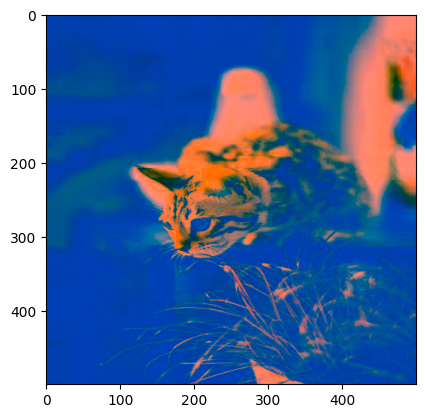

In [34]:
img = cv2.imread(r"/Users/antonfritsche/Desktop/Anton Fritsche/Programmierung/bell_repo/bell_repo/conv-network/cat.png")
img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
img_plot_rgb = plt.imshow(img)

In [35]:
img = Image.open(r"/Users/antonfritsche/Desktop/Anton Fritsche/Programmierung/bell_repo/bell_repo/conv-network/cat.png")
img = img.convert("L") # converts normally to grayscale
img = img.show() # opens image normal

Training des Modells mit verschiedenen Hyperparametern

In [40]:
module_path = os.path.abspath(os.path.join('..', 'conv-network'))

if module_path not in sys.path:
    sys.path.append(module_path)

# noinspection PyUnresolvedReferences
from model import ConvModel

conv_model = ConvModel()
print(conv_model)


ConvModel(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=2, bias=True)
)


In [41]:
loss_fn = torch.nn.MSELoss()

In [42]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

def target_transform_func(target):
    target = torch.tensor(target, dtype=torch.float32)
    normalized_label  = torch.div(target, 128) # rescale target to the range (-1; 1) for better data handling for the model
    return normalized_label

class ABSectionDataset(Dataset):
    def __init__(self, csv_file, image_dir_param, transform_func=None, target_transform_param=None):
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir_param
        self.transform = transform_func
        self.target_transform = target_transform_param

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.data.iloc[idx, 0])

        image = Image.open(img_path)

        if image.mode != "L":
            image = image.convert("L")

        label = self.data.iloc[idx, 1:3].values.astype(np.float32)

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [ ]:
csv_path = r"E:\Programmierung\Datein\Python\bell_repo\conv-network\data.csv"
data = pd.read_csv(csv_path)

image_dir = r"F:\Projekte\bell_repo\conv_netzwerk_dataset\train"

dataset = ABSectionDataset(csv_file=csv_path, image_dir_param=image_dir, transform_func=transform, target_transform_param=target_transform_func)

subset_indices = list(range(24999))
subset = Subset(dataset, subset_indices)

train_size = int(0.9 * len(subset))
val_size = len(subset) - train_size

train_dataset, val_dataset = random_split(subset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conv_model.to(device)
start_time = time()

In [ ]:
for epoch in range(num_epochs):
    epoch_time = time()
    conv_model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        # noinspection DuplicatedCode
        images, targets = images.to(device), targets.to(device)
        # print(f"images.shape: {images.shape}")
        # Forward pass
        # print(images[:1][:1])
        outputs = conv_model(images)

        rescaled_outputs = torch.mul(outputs, 128) # scale the outputs back to lab color space
        rescaled_targets = torch.mul(targets, 128) # scale the targets back to lab color space

        loss = loss_fn(rescaled_outputs, rescaled_targets)
        training_loss_ot.append(loss.item()) # loss.item() returns the value of tensor as Python number
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # noinspection PyUnboundLocalVariable
    print(f"rescaled targets: {[round(val, 4) for val in rescaled_targets[0].tolist()]}")
    # noinspection PyUnboundLocalVariable
    print(f"rescaled outputs: {[round(val, 4) for val in rescaled_outputs[0].tolist()]}")
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

    # Validation (optional)
    conv_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            # noinspection DuplicatedCode
            images, targets = images.to(device), targets.to(device)
            outputs = conv_model(images)

            rescaled_outputs_loss = torch.mul(outputs, 128) # scale the outputs back to lab color space
            rescaled_targets_loss = torch.mul(targets, 128)

            loss = loss_fn(rescaled_outputs_loss, rescaled_targets_loss)
            validation_loss_ot.append(loss.item())  # loss.item() returns the value of tensor as Python number
            val_loss += loss.item()
    print(f"Validation Loss: {val_loss/len(val_loader):.4f}")
    print(f"Epoch time: {time.time() - epoch_time:.2f} seconds")
    print("\n")
elapsed_time = time.time() - start_time
# noinspection PyUnboundLocalVariable
print(f"Training time: {elapsed_time:.2f} seconds")